In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

1) Exploration initiale

In [191]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("vgsales.csv")

df.shape
df.info()
df.describe()
df.head()
df.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  str    
 2   Platform      16598 non-null  str    
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  str    
 5   Publisher     16540 non-null  str    
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), str(4)
memory usage: 1.4 MB


Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

L’exploration initiale du dataset montre que la colonne Publisher contient 58 valeurs manquantes, tandis que la colonne Year en contient 271.
Ces valeurs manquantes expliquent pourquoi Year est au format float : les NaN obligent pandas à utiliser un type numérique compatible.

2) Inspection des valeurs manquantes

In [192]:
yearVoid = df["Year"][df["Year"].isna()]
publisherVoid = df["Publisher"][df["Publisher"].isna()]

print(yearVoid)
print(publisherVoid)

print(len(yearVoid))
print(len(publisherVoid))


179     NaN
377     NaN
431     NaN
470     NaN
607     NaN
         ..
16307   NaN
16327   NaN
16366   NaN
16427   NaN
16493   NaN
Name: Year, Length: 271, dtype: float64
470      NaN
1303     NaN
1662     NaN
2222     NaN
3159     NaN
3166     NaN
3766     NaN
4145     NaN
4526     NaN
4635     NaN
5302     NaN
5647     NaN
6272     NaN
6437     NaN
6562     NaN
6648     NaN
6849     NaN
7208     NaN
7351     NaN
7470     NaN
7953     NaN
8330     NaN
8341     NaN
8368     NaN
8503     NaN
8770     NaN
8848     NaN
8896     NaN
9517     NaN
9749     NaN
10382    NaN
10494    NaN
11076    NaN
11526    NaN
12487    NaN
12517    NaN
13278    NaN
13672    NaN
13962    NaN
14087    NaN
14296    NaN
14311    NaN
14698    NaN
14942    NaN
15056    NaN
15261    NaN
15325    NaN
15353    NaN
15788    NaN
15915    NaN
16191    NaN
16198    NaN
16208    NaN
16229    NaN
16367    NaN
16494    NaN
16543    NaN
16553    NaN
Name: Publisher, dtype: str
271
58


La colonne Publisher contient 58 valeurs manquantes, et la colonne Year en contient 271.
Les valeurs manquantes dans Publisher peuvent être remplacées par "Unknown", ce qui est cohérent pour une variable textuelle.
En revanche, les valeurs manquantes dans Year doivent rester sous forme de NaN tant que le nettoyage n’est pas terminé.

3 Nettoyage


3.1 Remplacement des valeurs manquantes dans Publisher

In [193]:
df["Publisher"] = df["Publisher"].fillna("Unknown")
df["Publisher"].unique()


<StringArray>
[                   'Nintendo',      'Microsoft Game Studios',
        'Take-Two Interactive', 'Sony Computer Entertainment',
                  'Activision',                     'Ubisoft',
          'Bethesda Softworks',             'Electronic Arts',
                        'Sega',                  'SquareSoft',
 ...
                   'Nitroplus',         'Paradox Development',
                     'Otomate',                   'Ongakukan',
                    'Commseed',                'Inti Creates',
                      'Takuyo',          'Interchannel-Holon',
                  'Rain Games',           'UIG Entertainment']
Length: 578, dtype: str

Toutes les valeurs manquantes dans Publisher ont été remplacées par "Unknown".
Ce choix permet de conserver l’information tout en évitant de casser le type de la colonne.

3.2 Conversion de Year en entier

In [ ]:
df["Year"] = pd.to_numeric(df["Year"], errors="coerce").astype("Int64")
df["Year"].head()

0    2006
1    1985
2    2008
3    2009
4    1996
Name: Year, dtype: Int64

La colonne Year a été convertie en entier (Int64), un type qui permet de conserver les NaN tout en représentant correctement les années.

4) Visualisations

Pour simplifier et aléger les schéma on va introduire une nouvelle colonne décennie 

In [216]:
df["Decennie"] = (df["Year"] // 10) * 10
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Decennie
0,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74,2000
1,2,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,1980
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82,2000
3,4,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00,2000
4,5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,1990


4.1 Nombre de jeu par décenie


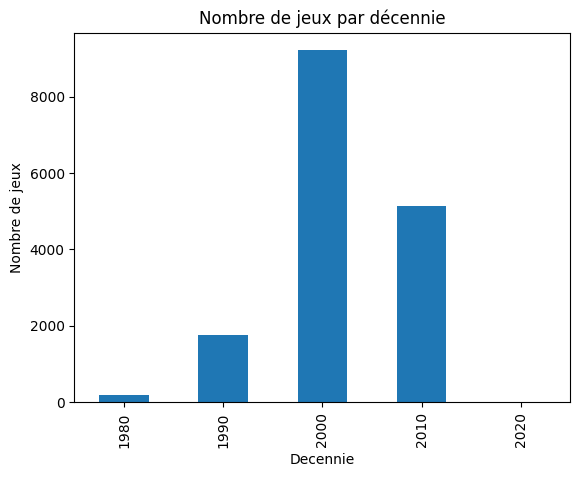

In [220]:
df["Decennie"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Decennie")
plt.ylabel("Nombre de jeux")
plt.title("Nombre de jeux par décennie")
plt.show()


L’analyse par décennie montre une forte augmentation du nombre de jeux publiés dans les années 2000, ce qui correspond à l’âge d’or du marché du jeu vidéo avec les consoles PS2, Wii, DS, Xbox 360 et PS3.

On observe ensuite une baisse apparente dans la décennie 2010–2020. Cette diminution n’est pas due à un ralentissement réel de l’industrie, mais au fait que le dataset s’arrête en 2016.

La décennie 2010 n’est donc représentée que par les années 2010 à 2016, ce qui explique naturellement le nombre plus faible de jeux enregistrés pour cette période.

4.2 Nombre de jeux par genre

In [211]:
genreGroupe = df.groupby("Genre")
genreGroupe.size()

Genre
Action          3316
Adventure       1286
Fighting         848
Misc            1739
Platform         886
Puzzle           582
Racing          1249
Role-Playing    1488
Shooter         1310
Simulation       867
Sports          2346
Strategy         681
dtype: int64

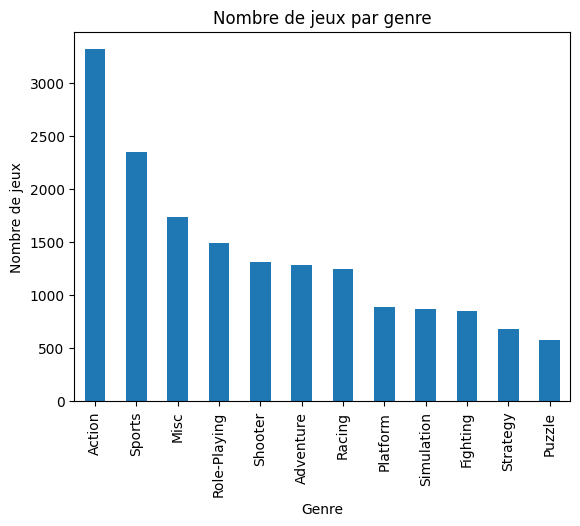

In [189]:
genreGroupe = df.groupby("Genre").size().sort_values(ascending=False)

genreGroupe.plot(kind="bar")
plt.xlabel("Genre")
plt.ylabel("Nombre de jeux")
plt.title("Nombre de jeux par genre")
plt.show()


4.3  Vente global par genre

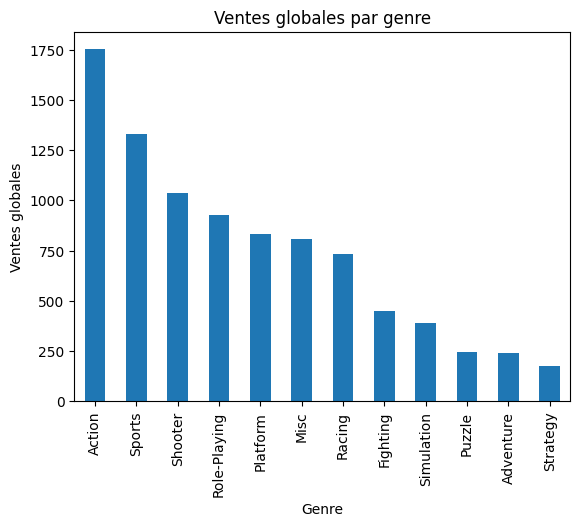

In [213]:
df.groupby("Genre")["Global_Sales"].sum().sort_values(ascending=False).plot(kind="bar")
plt.xlabel("Genre")
plt.ylabel("Ventes globales")
plt.title("Ventes globales par genre")
plt.show()


Les genres Action, Sports et Shooter sont les plus rentables.
Les genres Puzzle et Adventure génèrent beaucoup moins de ventes.

4.4 Ventes globales par décennie

Text(0, 0.5, 'Global sales')

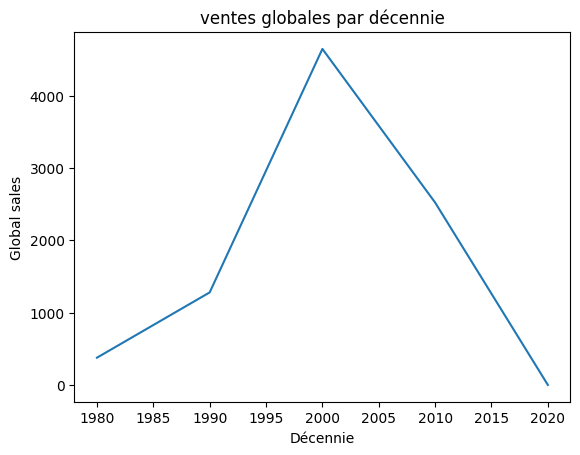

In [212]:
decennie = df.groupby("Decennie")
decennie.size()
sumBydecade = df.groupby("Decennie")["Global_Sales"].sum().sort_values(ascending=False)
sumBydecade.sort_index().plot(kind="line")
plt.xlabel("Décennie")
plt.title("ventes globales par décennie")
plt.ylabel("Global sales")

On remarque que les années 2010 et 2020 semblent si faibles. On pourrait se demander si le maché a baisser, mais la réponse est que la dataset a été collecté autour de 2016 ce qui explique pourquoi 2020 n'a quasiement rien et pourquoi l'année 2010 est incomplète

4.5 Ventes globales par plateforme

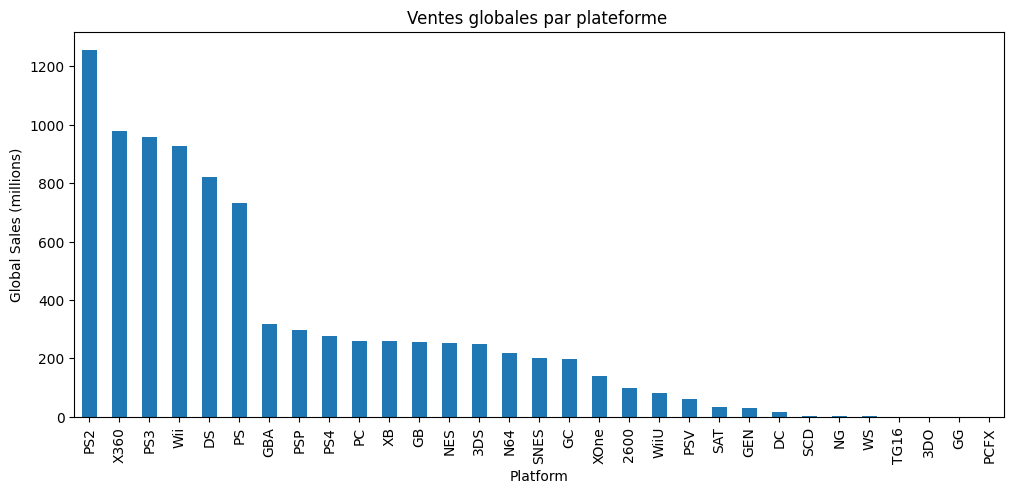

In [221]:
GlobalSumByPlatform = (
    df.groupby("Platform")["Global_Sales"]
      .sum()
      .sort_values(ascending=False)
)

GlobalSumByPlatform.plot(kind="bar", figsize=(12,5))
plt.xlabel("Platform")
plt.ylabel("Global Sales (millions)")
plt.title("Ventes globales par plateforme ")
plt.show()


Le graphique n'est pas très lisible on va donc faire le graphique avec le top 10 des platform

Text(0, 0.5, 'Global sales')

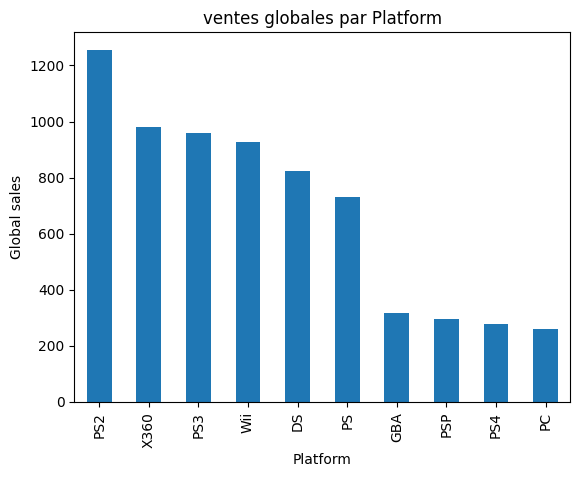

In [183]:
GlobalTop10SumByPlatform = GlobalSumByPlatform.head(10)

GlobalTop10SumByPlatform.plot(kind="bar")
plt.xlabel("Platform")
plt.title("ventes globales par Platform")
plt.ylabel("Global sales")


Les plateformes historiques comme PS2, X360, PS3 et Wii dominent largement les ventes globales.
Les plateformes plus anciennes ou plus confidentielles génèrent beaucoup moins de ventes